# 1 - Simple Pitch Analysis of Jazz Corpus

## Imports

In [384]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [401]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import preprocessing_utils as pp
from Importables import pitchanalysis_utils as pa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [406]:
import importlib
import Importables.preprocessing_utils

importlib.reload(Importables.preprocessing_utils)

<module 'Importables.preprocessing_utils' from '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/preprocessing_utils.py'>

## Load/Preprocess Data

In [408]:
path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/metadata.tsv"
metadata = pd.read_csv(path, sep='\t')
metadata.head(5)

,rel_paths,fnames,last_mc,last_mn,KeySig,TimeSig,label_count,annotated_key,composer,workTitle,...,staff_7_ambitus,staff_7_instrument,staff_8_ambitus,staff_8_instrument,staff_9_ambitus,staff_9_instrument,transcribed_instruments,transcribed_sections,transposition,year_certain
0,by_Alexander_Booker,Snarky_Puppy-Shapons_Vindaloo,142,142,"1: 0, 113: -3, 134: 0","1: 9/8, 2: 7/8, 4: 9/8, 5: 7/8, 7: 9/8, 8: 7/8...",8,NaN,Väsen,Shapons Vindaloo,...,NaN,NaN,NaN,NaN,NaN,NaN,"ac-g, e-g, b, nyckelharpa",complete,Concert Key,1
1,by_Alexander_Booker,The_Fearless_Flyers-Ace_of_Aces,57,57,1: 3,1: 4/4,2,NaN,Smith/Dart/Wong/Lettieri/Stratton,Ace Of Aces,...,NaN,NaN,NaN,NaN,NaN,NaN,"g, b, dr",complete,Concert Key,1
2,by_Alexander_Booker,Vulfpeck-Fugue_State,71,71,1: 0,1: 4/4,13,NaN,"Woody Goss, Jack Stratton",Fugue State,...,NaN,NaN,NaN,NaN,NaN,NaN,"ep, g, b, dr",complete,Concert Key,1
3,by_Carles_Margarit,12 Keys Blues - Bob Mintzer,156,156,1: 0,1: 4/4,169,NaN,NaN,12 Keys Blues,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,solo,Bb,1
4,by_Carles_Margarit,26_2 - Coltrane (Concert Key),298,297,1: -1,"1: 4/4, 296: 2/4, 298: 4/4",347,NaN,John Coltrane,26-2,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,complete,Concert Key,1


In [410]:
base_path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/notes"
dfs = pp.harmony_df(metadata, base_path)

In [412]:
dfs

,order,note,pc,artists,workTitle,fnames,recording_year
0,1.3750,"[G#/Ab, D, G#/Ab]","[8, 2]",Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
1,2.0000,"[G, G, D, G]","[2, 7]",Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
2,2.2500,[F],[5],Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
3,2.5000,[G],[7],Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
4,3.0000,[G],[7],Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
...,...,...,...,...,...,...,...
182089,64.3750,[A],[9],Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,1978
182090,64.4375,[C],[0],Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,1978
182091,64.5000,[F],[5],Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,1978
182092,64.7500,[C#/Db],[1],Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,1978


In [414]:
test = dfs[dfs['fnames']=='Blues By Five - John Coltrane (Concert Key)']
test

,order,note,pc,artists,workTitle,fnames,recording_year
17854,2.500,[G#/Ab],[8],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
17855,2.625,[A#/Bb],[10],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
17856,2.875,[C],[0],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
17857,3.000,[C],[0],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
17858,3.125,[D#/Eb],[3],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
...,...,...,...,...,...,...,...
18329,84.125,[F],[5],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
18330,84.250,[G],[7],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
18331,84.375,[A#/Bb],[10],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956
18332,84.500,[A],[9],John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956


### Plot pitch profiles by standard

In [253]:
title_grouped, ref = pp.groupby_standard(dfs, length=3)
title_grouped.head(5)

,order,note,pc,artists,workTitle,fnames,recording_year
0,1.375,"[G#/Ab, D, G#/Ab]","[8, 2]",Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
1,2.000,"[G, G, D, G]","[2, 7]",Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
2,2.250,[F],[5],Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
3,2.500,[G],[7],Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015
4,3.000,[G],[7],Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015


In [255]:
subset = title_grouped.groupby(['workTitle', 'artists', 'fnames']).agg({
    'order': list,
    'note': list,
    'pc': list,
    'recording_year': 'first'  # <-- example: don't make this a list
}).reset_index().copy()

subset = subset[(subset['artists'] == 'John Coltrane') | (subset['artists'] == 'Miles Davis')].copy()
subset = subset.groupby('workTitle').agg(list).reset_index()
subset = subset[subset['artists'].apply(lambda x: len(x) > 1)].copy()

subset

,workTitle,artists,fnames,order,note,pc,recording_year
2,Blues By Five,"[John Coltrane, Miles Davis]","[Blues By Five - John Coltrane (Concert Key), ...","[[2.5, 2.625, 2.875, 3.0, 3.125, 3.375, 3.5, 3...","[[[G#/Ab], [A#/Bb], [C], [C], [D#/Eb], [F], [F...","[[[8], [10], [0], [0], [3], [5], [5], [8], [10...","[1956, 1956]"
3,Four,"[John Coltrane, Miles Davis]","[Four - John Coltrane (Concert Key), Four - Mi...","[[9.625, 9.75, 9.875, 10.125, 10.25, 10.375, 1...","[[[A#/Bb], [C], [D], [A#/Bb], [C], [D], [A#/Bb...","[[[10], [0], [2], [10], [0], [2], [10], [0], [...","[1956, 1956]"


In [308]:
subset['fnames'].explode()

2    Blues By Five - John Coltrane (Concert Key)
2      Blues By Five - Miles Davis (Concert Key)
3             Four - John Coltrane (Concert Key)
3               Four - Miles Davis (Concert Key)
Name: fnames, dtype: object

In [286]:
# takes a df with a single row and checks if the list in columns have same length
def check_column_list_lengths(row_df, columns):
    if row_df.shape[0] != 1:
        raise ValueError("This function expects a DataFrame with exactly 1 row!")
    
    # Get the length of the first column's list
    target_length = len(row_df.iloc[0][columns[0]])
    
    for col in columns[1:]:
        current_length = len(row_df.iloc[0][col])
        
        if current_length != target_length:
            return False
    
    return True

data = {}
songs = []

for row in range(subset.shape[0]):
    subset_row = subset.iloc[[row]]
    worktitle = subset_row.iloc[0]['workTitle']
    songs.append(worktitle)
    
    # Check column lengths
    result = check_column_list_lengths(subset_row, ['order', 'note', 'pc'])
    
    if not result:
        raise ValueError(f"List lengths do not match! Song: {worktitle}")
    
    # Now build data dictionary
    num_artists = len(subset_row.iloc[0]['artists'])
    
    for i in range(num_artists):
        artist = (subset_row.iloc[0]['artists'])[i]
        note = (subset_row.iloc[0]['note'])[i]

        key = (worktitle, artist)
        data[key] = note

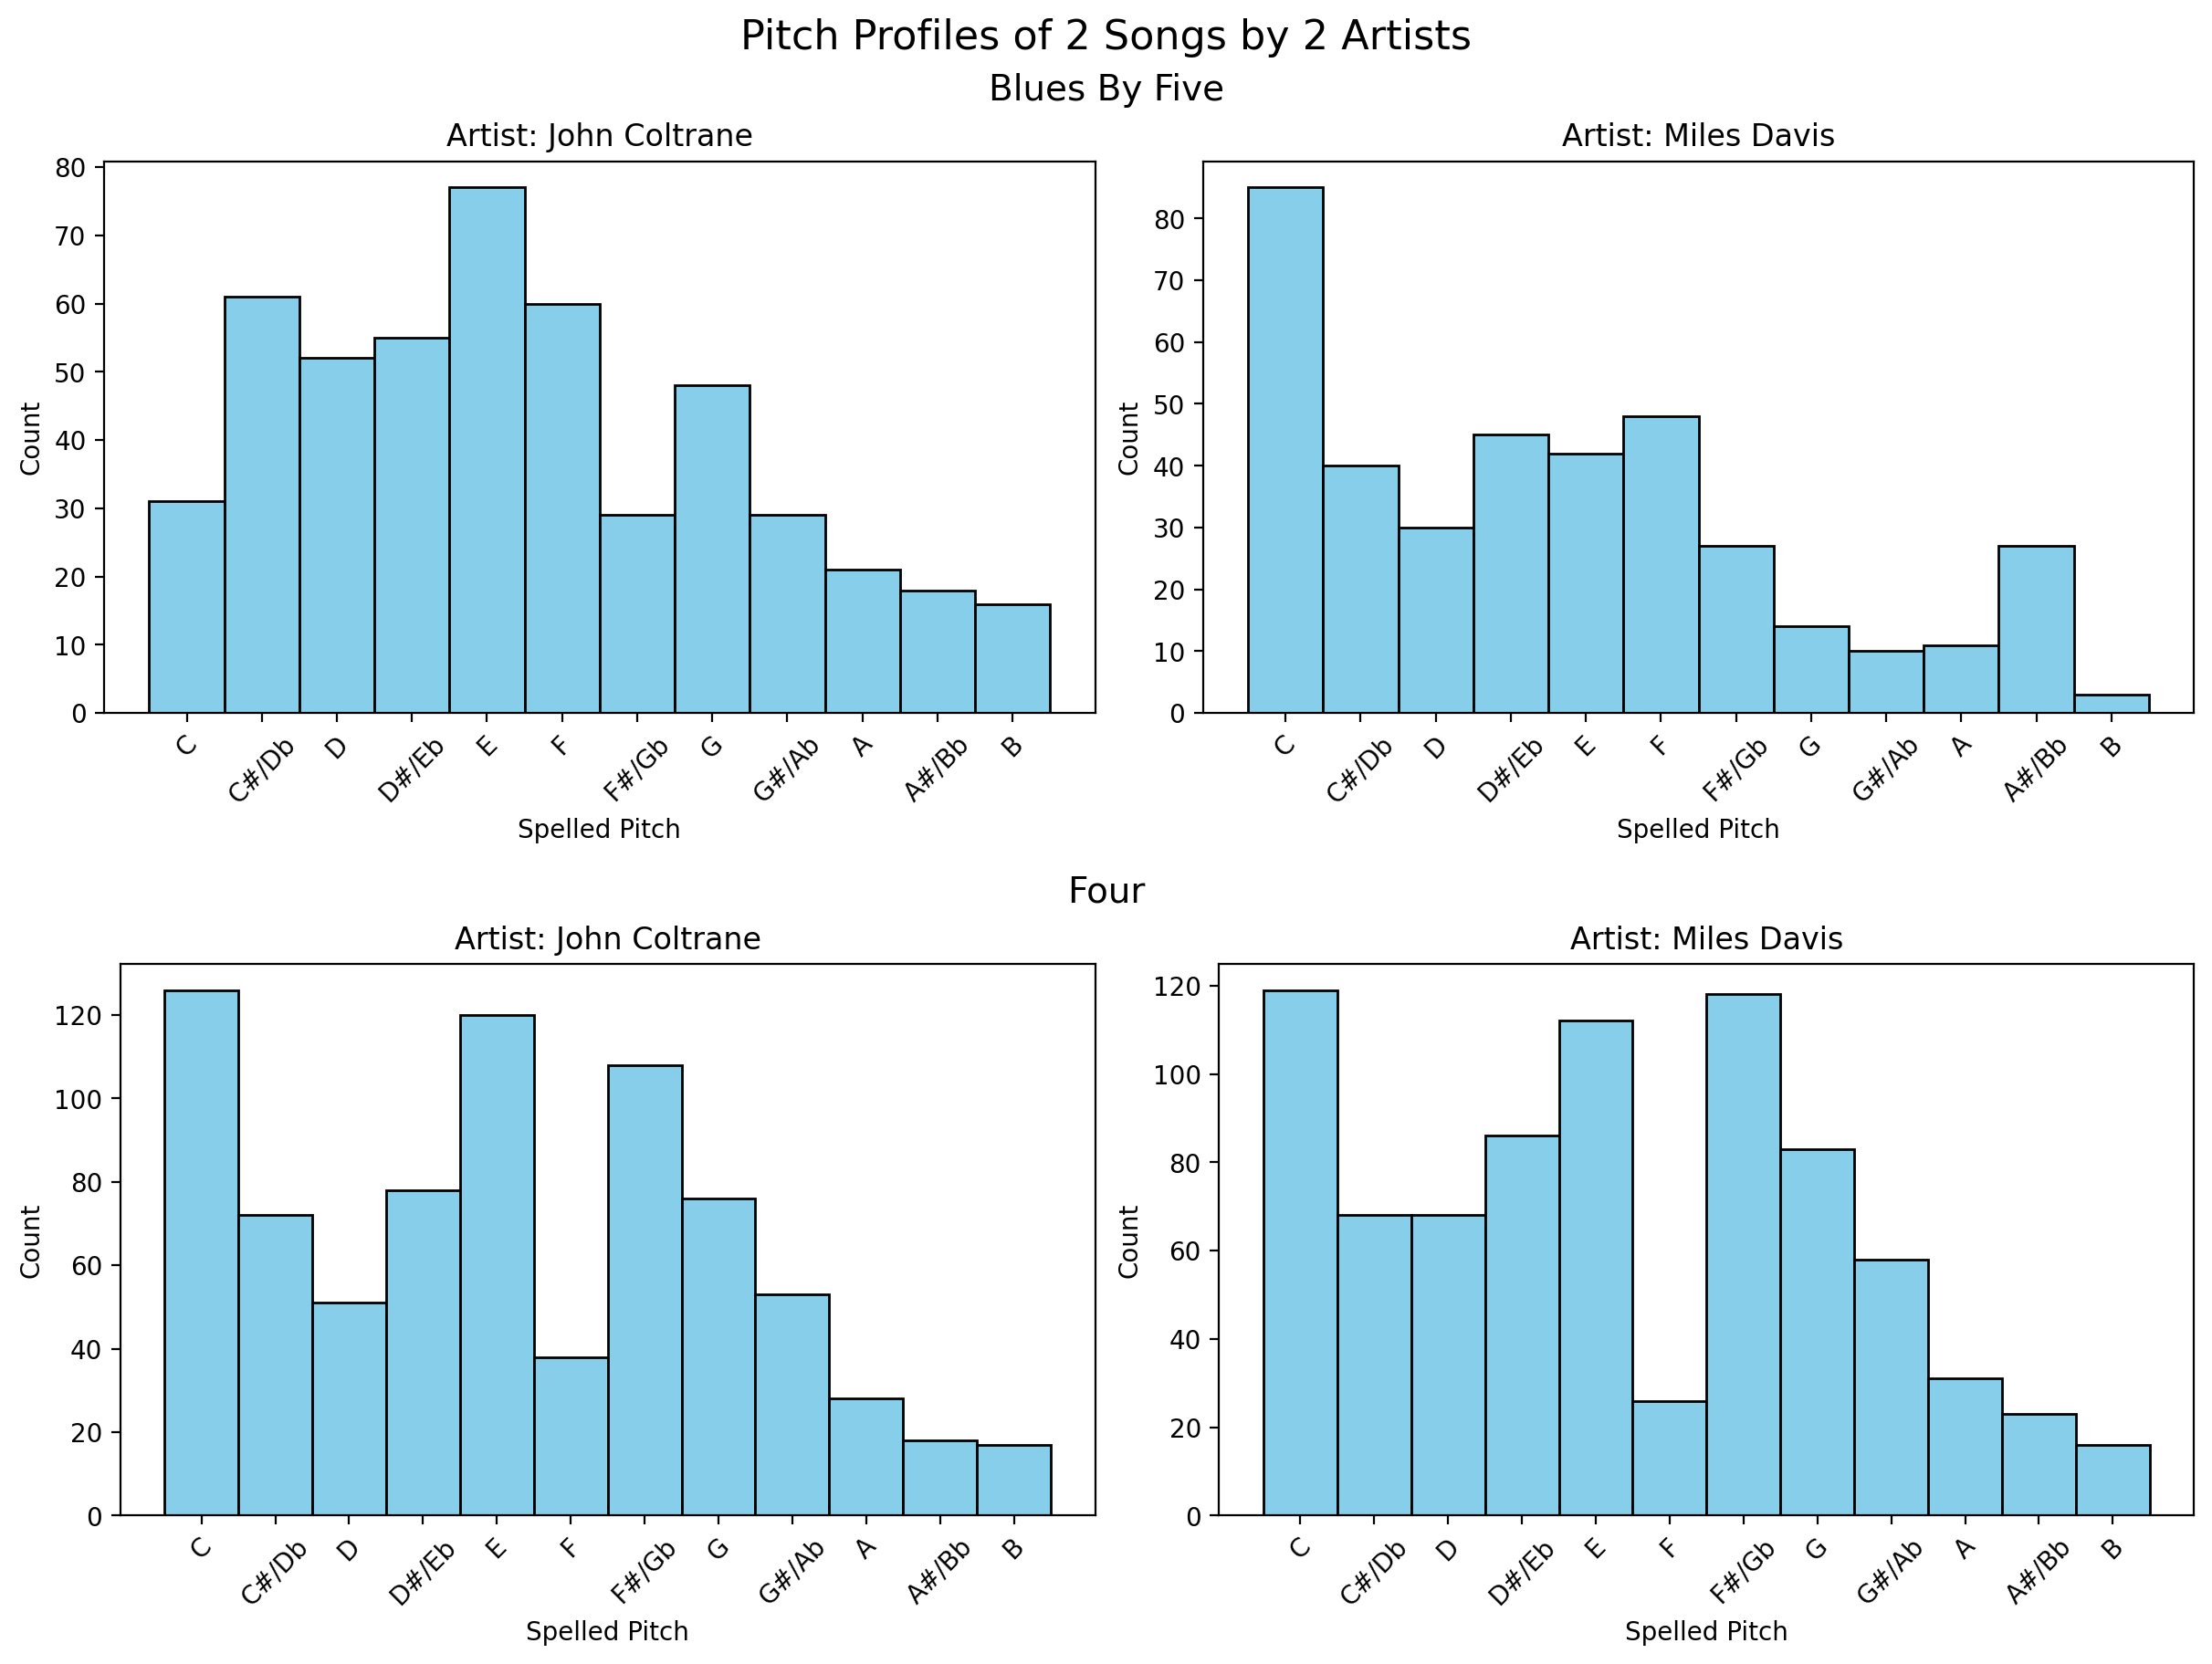

In [302]:
# --- Plot ---
fig = plt.figure(figsize=(12, 9),constrained_layout=True)
subfigs = fig.subfigures(nrows=2, ncols=1)

for i, song in enumerate(songs):
    subfig = subfigs[i]
    subfig.suptitle(f'{song}', fontsize=14)
    
    axs = subfig.subplots(nrows=1, ncols=2)
    
    # Get artists for this song (from subset)
    subset_row = subset[subset['workTitle'] == song]
    artists = subset_row.iloc[0]['artists']
    
    for j, artist in enumerate(artists):
        ax = axs[j]
        
        # Get the pitch profile data:
        pitch_data = [item for sublist in data[(song, artist)] for item in sublist]
        
        # Plot histogram:
        ax.hist(pitch_data, bins=np.arange(13)-0.5, color='skyblue', edgecolor='black')
        
        # Set labels:
        ax.set_title(f'Artist: {artist}')
        ax.set_xlabel('Spelled Pitch')
        ax.set_ylabel('Count')
        
        # Use spelled pitch on x-axis:
        ax.set_xticks(np.arange(12))
        ax.set_xticklabels(pitch_class_names, rotation=45)

# Global figure title:
fig.suptitle('Pitch Profiles of 2 Songs by 2 Artists', fontsize=16)

plt.show()

## Questions to ask: 
1. Double check and make sure that I'm converting midi to spelled pitch correctly
2. 
3. How do we determine the time frame of the pieces to compare
